# Airbnb Data Analysis and Price Prediction using Machine Learning

## 1. Introduction

Airbnb is a popular online platform that connects hosts who provide
accommodation with guests looking for short-term or long-term stays.
Airbnb generates a large amount of data related to property listings,
hosts, locations, room types, prices, reviews, minimum stay requirements,
and availability.

This project focuses on analyzing Airbnb listing data to identify
important patterns and relationships in the data. The project uses
Python-based Data Analytics and Machine Learning techniques to understand
the factors associated with Airbnb listing prices.

The analysis includes data cleaning, exploratory data analysis (EDA),
data visualization, feature engineering, and predictive modeling.

Two Machine Learning algorithms, Linear Regression and Random Forest
Regression, are used to predict the price of Airbnb listings. The models
are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error
(RMSE), and R² Score.

The main purpose of this project is to demonstrate how real-world Airbnb
data can be transformed into meaningful insights and used to build a
price prediction model.

## 2. Problem Statement

Airbnb listings can have significantly different prices depending on
factors such as location, room type, minimum nights, number of reviews,
availability, and other listing characteristics.

Understanding these patterns manually can be difficult when dealing with
a large dataset.

Therefore, this project aims to analyze Airbnb listing data, identify
important pricing patterns, generate useful business insights, and
develop Machine Learning models that can predict listing prices.

## 3. Aim of the Project

The main aim of this project is to perform an end-to-end analysis of
Airbnb listing data and develop a Machine Learning model for predicting
Airbnb prices.

## 4. Objectives

The major objectives of this project are:

- To understand and explore the Airbnb dataset.
- To clean and preprocess the raw data.
- To identify and handle missing values.
- To analyze Airbnb listings using Exploratory Data Analysis.
- To create meaningful data visualizations.
- To study price variations across room types and locations.
- To identify important business insights from the data.
- To prepare suitable features for Machine Learning.
- To build Linear Regression and Random Forest Regression models.
- To evaluate model performance using MAE, RMSE, and R² Score.
- To compare the performance of the Machine Learning models.
- To demonstrate the practical use of Data Analytics and Machine Learning.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [51]:
df = pd.read_csv("../data/AB_NYC_2019.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (48895, 16)


In [52]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [53]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [54]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 48895
Number of Columns: 16


In [55]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [57]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 5. Dataset Understanding

The Airbnb dataset contains information about Airbnb listings,
including listing details, host information, location, room type,
price, minimum nights, reviews, and availability.

The dataset contains 48,895 records and 16 columns.

Initial dataset exploration was performed using:
- `head()` to view the first records
- `tail()` to view the last records
- `shape` to understand dataset dimensions
- `columns` to identify available features
- `info()` to examine data types and missing values
- `describe()` to obtain statistical summaries

In [58]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [59]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Values Percentage:")
print(missing_percentage.round(2))

Missing Values Percentage:
id                                 0.00
name                               0.03
host_id                            0.00
host_name                          0.04
neighbourhood_group                0.00
neighbourhood                      0.00
latitude                           0.00
longitude                          0.00
room_type                          0.00
price                              0.00
minimum_nights                     0.00
number_of_reviews                  0.00
last_review                       20.56
reviews_per_month                 20.56
calculated_host_listings_count     0.00
availability_365                   0.00
dtype: float64


In [60]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Percentage
name,16,0.03
host_name,21,0.04
last_review,10052,20.56
reviews_per_month,10052,20.56


## 6. Missing Values Analysis

Missing value analysis was performed to identify incomplete records
in the Airbnb dataset.

The analysis showed that some columns contain missing values.
These missing values need to be handled appropriately before performing
further analysis and Machine Learning.

Missing values were analyzed using both their total count and
percentage of the complete dataset.

In [61]:
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["last_review"] = df["last_review"].fillna("Not Reviewed")

print("Missing values handled successfully!")

Missing values handled successfully!


In [62]:
print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


## 7. Data Cleaning - Missing Values Handling

Missing values were handled based on the meaning of each feature.

- Missing listing names were replaced with "Unknown".
- Missing host names were replaced with "Unknown".
- Missing review frequency values were replaced with 0 because the
  corresponding listings had no recorded reviews.
- Missing last review dates were labeled as "Not Reviewed".

This approach helps preserve the available records instead of
unnecessarily deleting rows from the dataset.

In [63]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [64]:
df = df.drop_duplicates()

print("Duplicate records removed successfully!")
print("New Dataset Shape:", df.shape)

Duplicate records removed successfully!
New Dataset Shape: (48895, 16)


## 8. Duplicate Records Handling

Duplicate records were checked to ensure that the dataset does not
contain repeated observations.

Duplicate rows, if present, were removed using the `drop_duplicates()`
method. This helps improve data quality and prevents repeated records
from affecting the analysis and Machine Learning models.

In [65]:
print("Data Types of All Columns:")
print(df.dtypes)

Data Types of All Columns:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     48895 non-n

In [67]:
df["last_review"] = pd.to_datetime(
    df["last_review"],
    errors="coerce"
)

print("last_review converted to datetime format.")
print(df["last_review"].dtype)

last_review converted to datetime format.
datetime64[us]


## 9. Data Types Cleaning

The data types of all columns were checked before performing further
analysis.

Numerical features such as price, latitude, longitude, minimum nights,
number of reviews, and availability were kept in numerical format.

The `last_review` column was converted into a datetime format to make
date-based analysis easier.

Correct data types help improve the reliability of statistical analysis,
visualization, and Machine Learning.

In [72]:
print("Missing Values by Column:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nDataset Shape:", df.shape)

Missing Values by Column:
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Duplicate Records: 0

Dataset Shape: (48895, 16)


## 10. Final Data Quality Check

After the initial data cleaning process, a final quality check was
performed on the dataset.

Duplicate records were checked and no duplicate records were found.

The `last_review` column contains 10,052 missing date values. These
values represent listings that do not have a recorded review date.
They are retained as `NaT` because they indicate that no review date
is available.

The dataset is now ready for Exploratory Data Analysis (EDA).

In [73]:
room_counts = df["room_type"].value_counts()

print(room_counts)

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


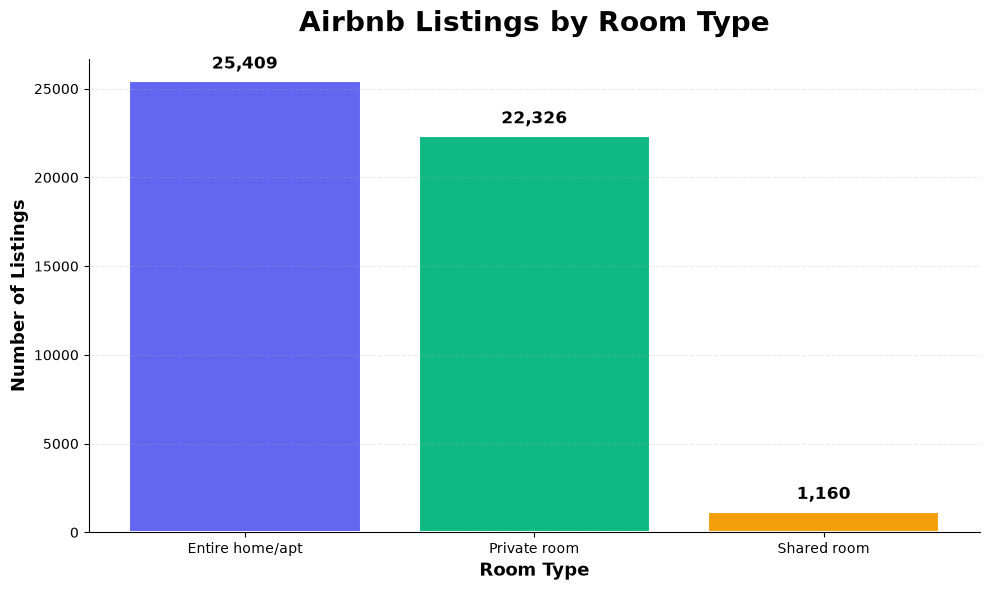

In [76]:
plt.figure(figsize=(10, 6))

room_counts = df["room_type"].value_counts()

bars = plt.bar(
    room_counts.index,
    room_counts.values,
    color=["#6366F1", "#10B981", "#F59E0B"],
    edgecolor="white",
    linewidth=1.5
)

plt.title(
    "Airbnb Listings by Room Type",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Room Type",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Listings",
    fontsize=13,
    fontweight="bold"
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Light grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()
plt.show()

# 11.1. Room Type Distribution

## Objective

The objective of this analysis is to understand the distribution of Airbnb
listings across different room types.

The dataset contains three major room types:

- Entire home/apt
- Private room
- Shared room

This analysis helps identify the most commonly available accommodation type
on Airbnb.

A colorful bar chart is used to compare the number of listings for each
room type and present the results in a clear and professional manner.

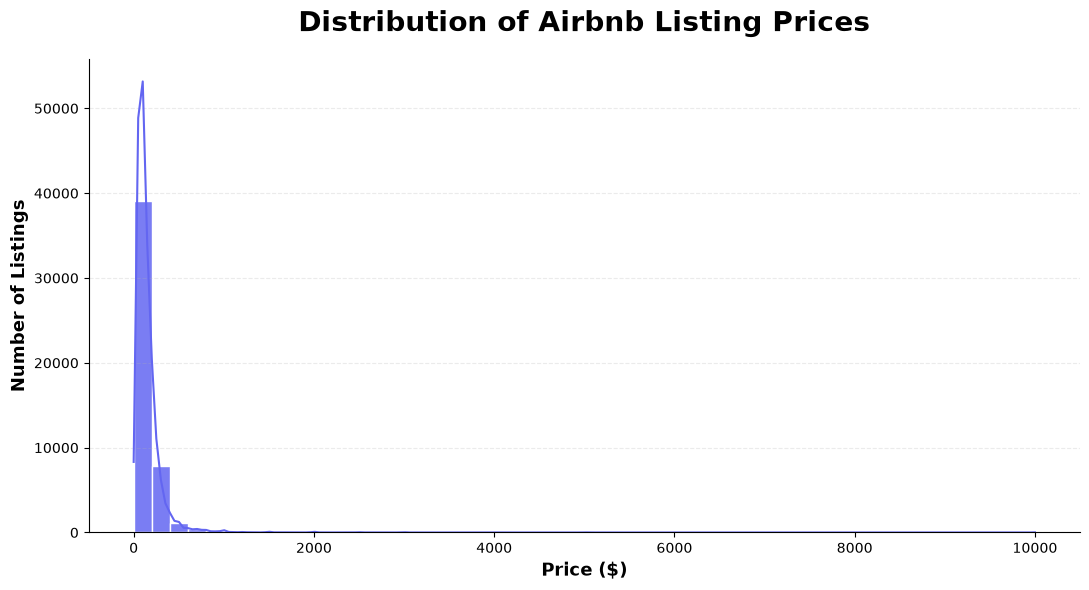

In [77]:
plt.figure(figsize=(11, 6))

sns.histplot(
    df["price"],
    bins=50,
    kde=True,
    color="#6366F1",
    edgecolor="white",
    alpha=0.85
)

plt.title(
    "Distribution of Airbnb Listing Prices",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Price ($)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Listings",
    fontsize=13,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.2. Price Distribution

## Objective

The objective of this analysis is to understand how Airbnb listing prices
are distributed across the dataset.

Price distribution helps identify common price ranges, variations in listing
prices, and the presence of unusually high-priced listings.

A histogram with a smooth density curve is used to present the price
distribution in a clear and professional way.

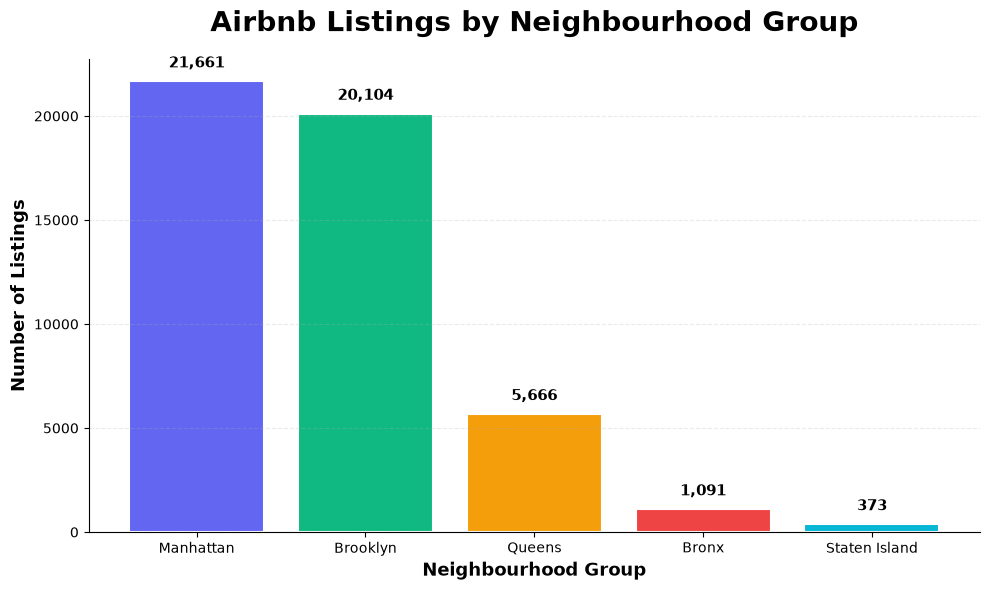

In [78]:
plt.figure(figsize=(10, 6))

neighbourhood_counts = df["neighbourhood_group"].value_counts()

bars = plt.bar(
    neighbourhood_counts.index,
    neighbourhood_counts.values,
    color=["#6366F1", "#10B981", "#F59E0B", "#EF4444", "#06B6D4"],
    edgecolor="white",
    linewidth=1.5
)

plt.title(
    "Airbnb Listings by Neighbourhood Group",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Neighbourhood Group",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Listings",
    fontsize=13,
    fontweight="bold"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.3. Listings by Neighbourhood Group

## Objective

The objective of this analysis is to compare the number of Airbnb listings
across different neighbourhood groups.

This analysis helps identify the areas with the highest concentration of
Airbnb properties and provides an overview of the geographical distribution
of listings.

A colorful bar chart is used to compare the number of listings across
neighbourhood groups.

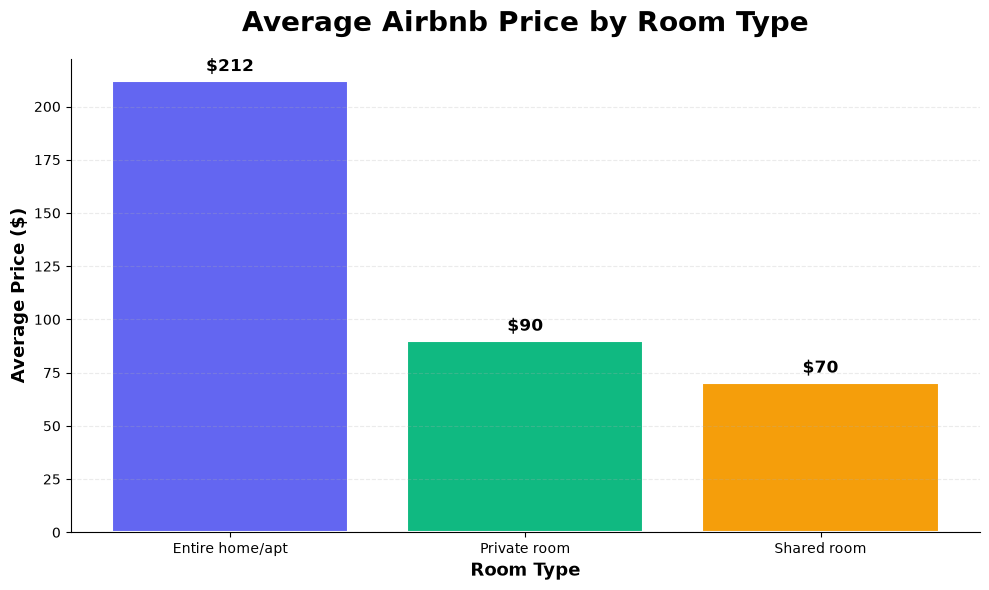

In [79]:
plt.figure(figsize=(10, 6))

avg_price_room = (
    df.groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

bars = plt.bar(
    avg_price_room.index,
    avg_price_room.values,
    color=["#6366F1", "#10B981", "#F59E0B"],
    edgecolor="white",
    linewidth=1.5
)

plt.title(
    "Average Airbnb Price by Room Type",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Room Type",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Average Price ($)",
    fontsize=13,
    fontweight="bold"
)

# Add average price labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.4. Average Price by Room Type

## Objective

The objective of this analysis is to compare the average price of
different Airbnb room types.

This analysis helps us understand how room type affects the pricing
of Airbnb listings.

A colorful bar chart is used to compare the average prices of
Entire home/apt, Private room, and Shared room listings.

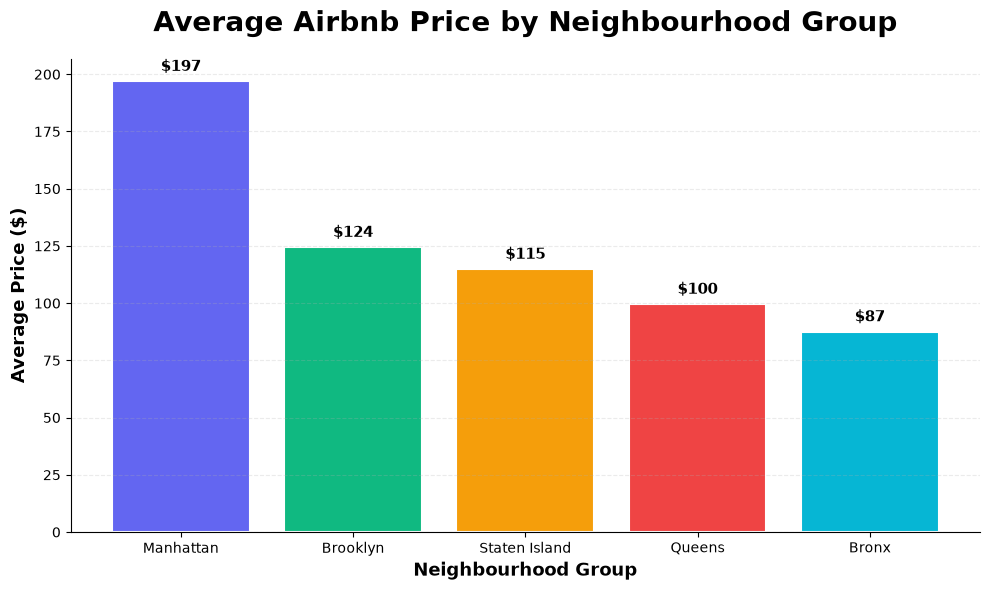

In [80]:
plt.figure(figsize=(10, 6))

avg_price_neighbourhood = (
    df.groupby("neighbourhood_group")["price"]
    .mean()
    .sort_values(ascending=False)
)

bars = plt.bar(
    avg_price_neighbourhood.index,
    avg_price_neighbourhood.values,
    color=["#6366F1", "#10B981", "#F59E0B", "#EF4444", "#06B6D4"],
    edgecolor="white",
    linewidth=1.5
)

plt.title(
    "Average Airbnb Price by Neighbourhood Group",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Neighbourhood Group",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Average Price ($)",
    fontsize=13,
    fontweight="bold"
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.5 Average Price by Neighbourhood Group

## Objective

The objective of this analysis is to compare the average Airbnb
listing price across different neighbourhood groups.

This analysis helps identify which neighbourhood groups have higher
or lower average Airbnb prices.

A colorful bar chart is used to make the comparison clear and
easy to understand.

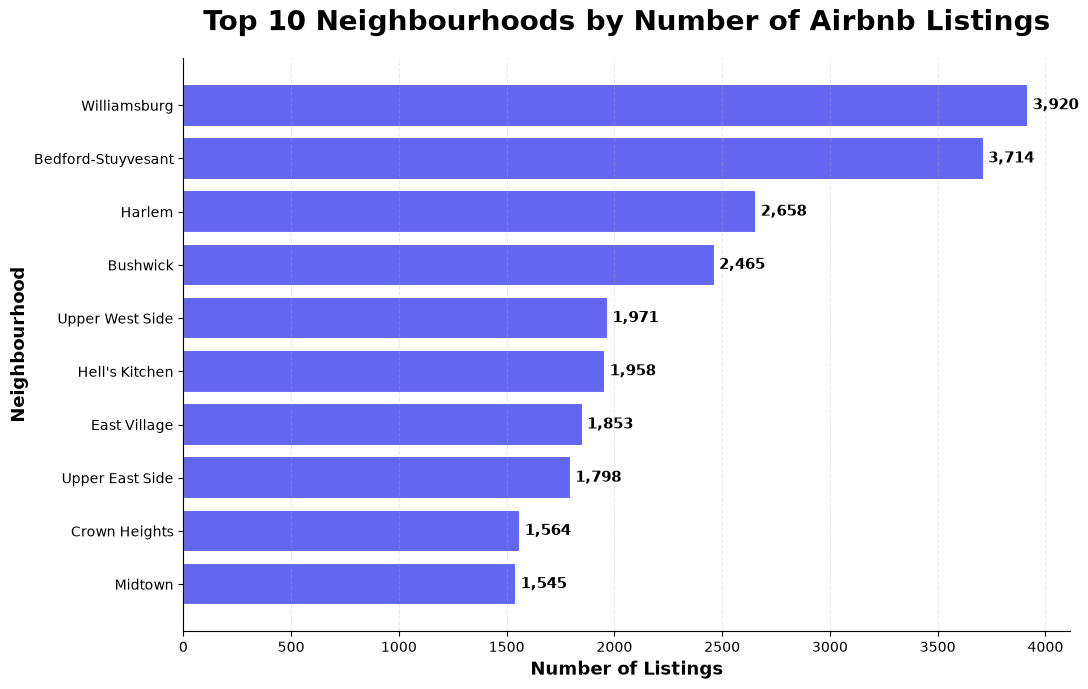

In [81]:
plt.figure(figsize=(11, 7))

top_neighbourhoods = (
    df["neighbourhood"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

bars = plt.barh(
    top_neighbourhoods.index,
    top_neighbourhoods.values,
    color="#6366F1",
    edgecolor="white",
    linewidth=1.5
)

plt.title(
    "Top 10 Neighbourhoods by Number of Airbnb Listings",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Number of Listings",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Neighbourhood",
    fontsize=13,
    fontweight="bold"
)

# Add values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.6 Top Neighbourhoods

## Objective

The objective of this analysis is to identify the neighbourhoods
with the highest number of Airbnb listings.

This analysis helps us understand which specific neighbourhoods
have the highest concentration of Airbnb properties.

The top 10 neighbourhoods are selected and displayed using a
horizontal bar chart for better readability.

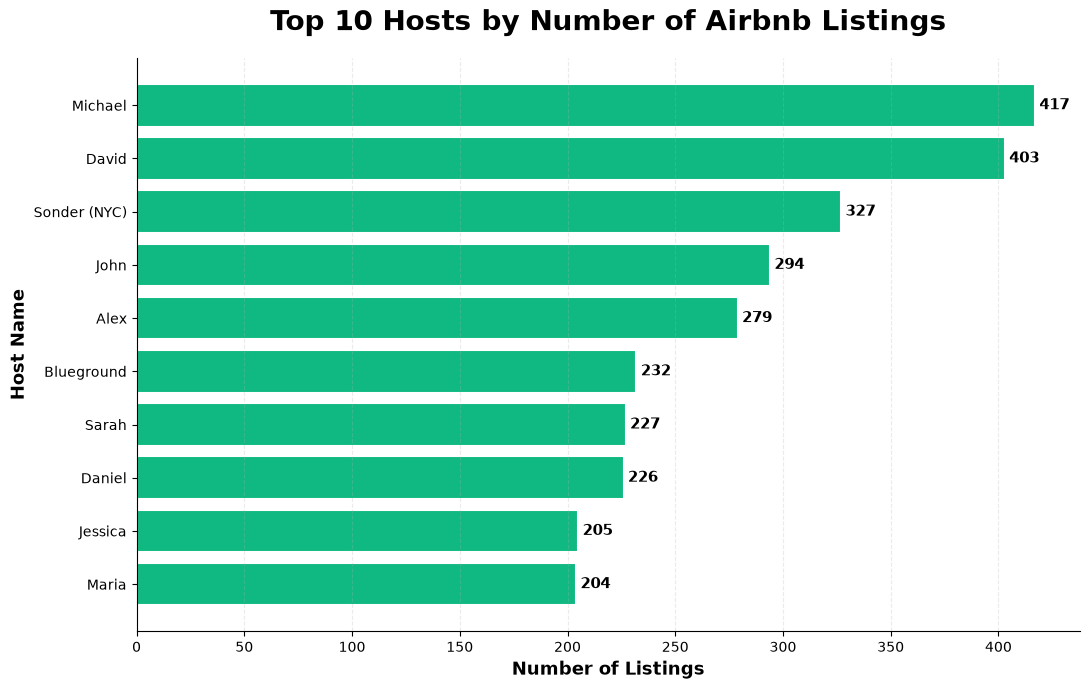

In [82]:
plt.figure(figsize=(11, 7))

top_hosts = (
    df["host_name"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

bars = plt.barh(
    top_hosts.index,
    top_hosts.values,
    color="#10B981",
    edgecolor="white",
    linewidth=1.5
)

plt.title(
    "Top 10 Hosts by Number of Airbnb Listings",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Number of Listings",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Host Name",
    fontsize=13,
    fontweight="bold"
)

# Add values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.7 Top Hosts

## Objective

The objective of this analysis is to identify the hosts who manage
the highest number of Airbnb listings.

This analysis helps us understand whether a small number of hosts
control a large number of properties on the platform.

The top 10 hosts are selected and displayed using a horizontal bar
chart for better readability.

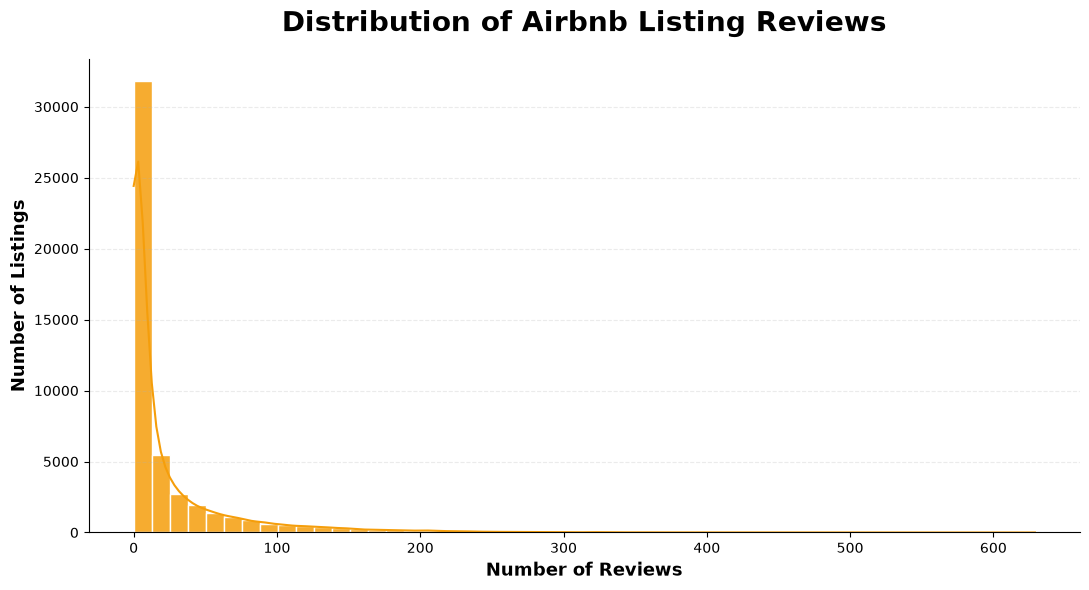

In [83]:
plt.figure(figsize=(11, 6))

sns.histplot(
    df["number_of_reviews"],
    bins=50,
    kde=True,
    color="#F59E0B",
    edgecolor="white",
    alpha=0.85
)

plt.title(
    "Distribution of Airbnb Listing Reviews",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Number of Reviews",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Listings",
    fontsize=13,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.8 Reviews Distribution

## Objective

The objective of this analysis is to understand the distribution of
the number of reviews received by Airbnb listings.

The number of reviews can provide an indication of guest activity
and the popularity of different listings.

A histogram is used to visualize how the number of reviews is
distributed across Airbnb listings.

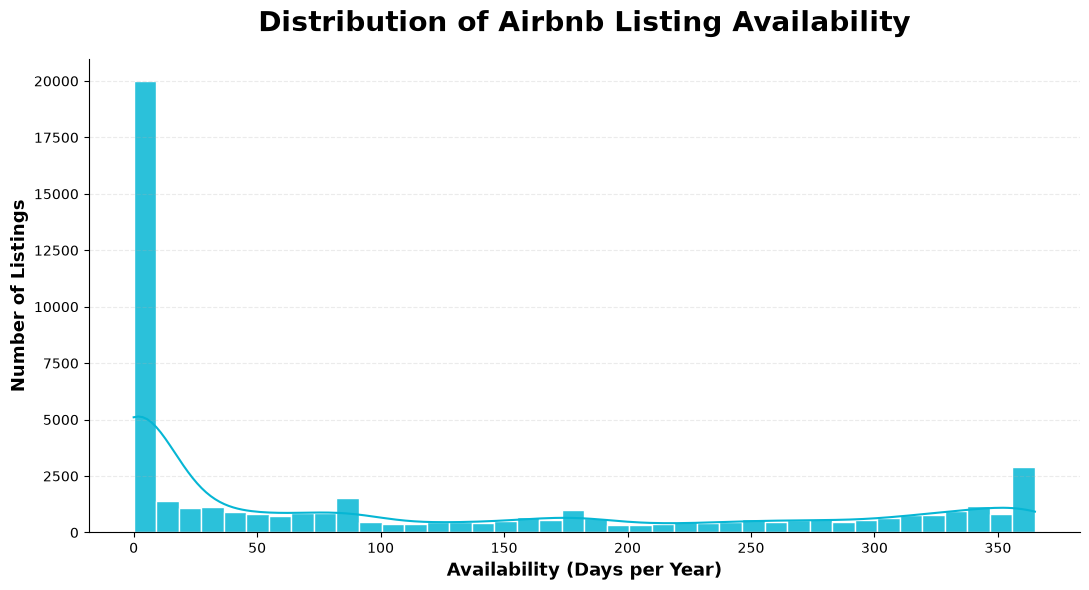

In [84]:
plt.figure(figsize=(11, 6))

sns.histplot(
    df["availability_365"],
    bins=40,
    kde=True,
    color="#06B6D4",
    edgecolor="white",
    alpha=0.85
)

plt.title(
    "Distribution of Airbnb Listing Availability",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Availability (Days per Year)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Listings",
    fontsize=13,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.9 Availability Distribution

## Objective

The objective of this analysis is to understand how many days per year
Airbnb listings are available for booking.

The `availability_365` feature represents the number of days a listing
is available during a year.

This analysis helps identify whether Airbnb properties are available
for most of the year or only for a limited number of days.

A histogram is used to visualize the distribution of listing
availability.

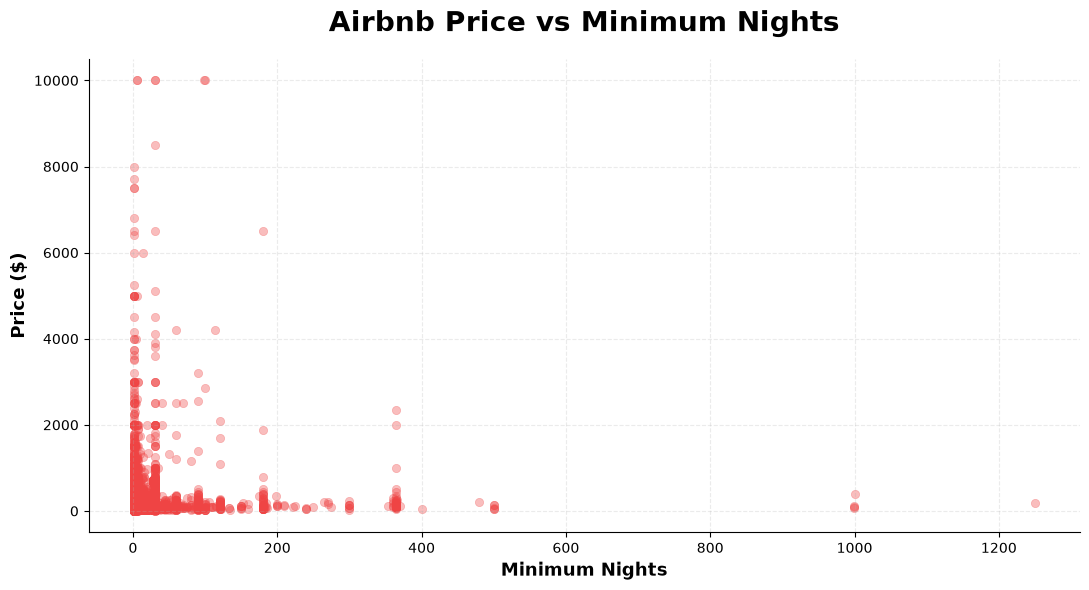

In [85]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="minimum_nights",
    y="price",
    alpha=0.35,
    color="#EF4444",
    edgecolor=None
)

plt.title(
    "Airbnb Price vs Minimum Nights",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Minimum Nights",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Price ($)",
    fontsize=13,
    fontweight="bold"
)

plt.grid(
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.10 Price vs Minimum Nights

## Objective

The objective of this analysis is to examine the relationship between
Airbnb listing price and the minimum number of nights required for a
booking.

A scatter plot is used to visualize whether listings requiring a
higher minimum stay tend to have different prices.

This analysis helps identify pricing patterns associated with minimum
stay requirements.

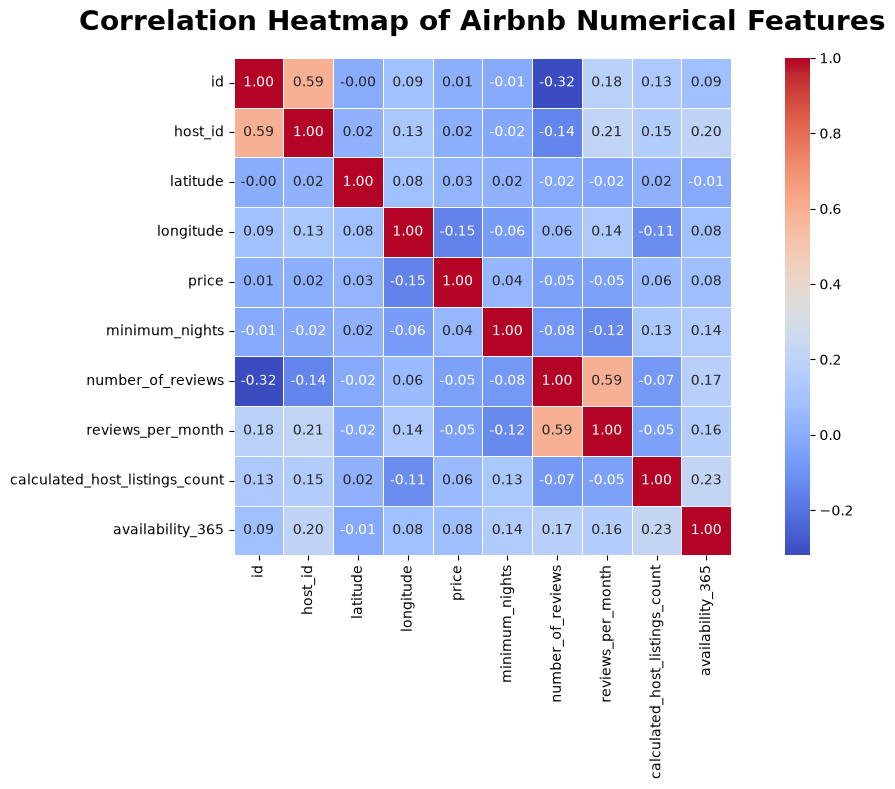

In [86]:
plt.figure(figsize=(12, 8))

# Select numerical columns
numerical_data = df.select_dtypes(
    include=["int64", "float64"]
)

# Calculate correlation
correlation_matrix = numerical_data.corr()

# Create heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap of Airbnb Numerical Features",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

# 11.11 Correlation Heatmap

## Objective

The objective of this analysis is to examine the relationships
between the numerical features of the Airbnb dataset.

Correlation shows the strength and direction of the relationship
between two numerical variables.

A heatmap is used to visualize these correlations. Values closer
to +1 indicate a strong positive relationship, values closer to -1
indicate a strong negative relationship, and values near 0 indicate
a weak or no linear relationship.

<Figure size 1100x700 with 0 Axes>

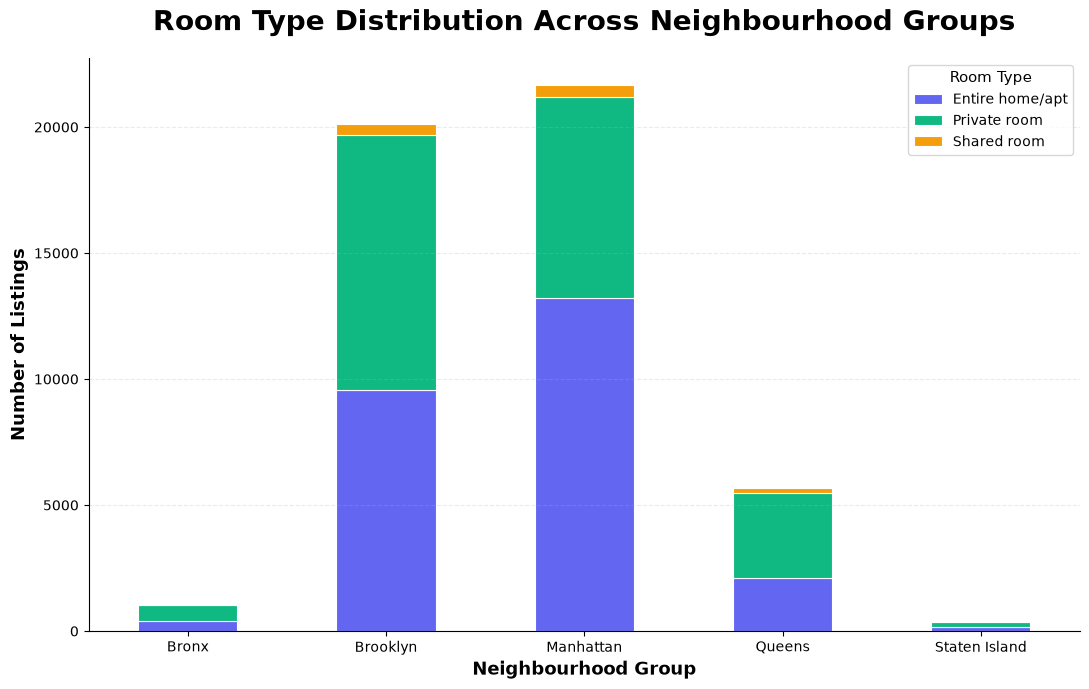

In [87]:
plt.figure(figsize=(11, 7))

room_neighbourhood = pd.crosstab(
    df["neighbourhood_group"],
    df["room_type"]
)

room_neighbourhood.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7),
    color=["#6366F1", "#10B981", "#F59E0B"],
    edgecolor="white",
    linewidth=0.8
)

plt.title(
    "Room Type Distribution Across Neighbourhood Groups",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Neighbourhood Group",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Number of Listings",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.legend(
    title="Room Type",
    title_fontsize=11
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

# 11.12 Room Type vs Neighbourhood Group

## Objective

The objective of this analysis is to compare the distribution of
different Airbnb room types across neighbourhood groups.

This analysis helps us understand which room types are most common
in different geographical areas.

A stacked bar chart is used to show the contribution of each room
type within every neighbourhood group.

#  Exploratory Data Analysis Summary

Exploratory Data Analysis was performed to understand the major patterns
and relationships present in the Airbnb dataset.

The analysis covered:

- Distribution of Airbnb listings by room type.
- Distribution of listing prices.
- Number of listings across neighbourhood groups.
- Average price comparison across room types.
- Average price comparison across neighbourhood groups.
- Top neighbourhoods based on listing count.
- Top hosts based on number of listings.
- Distribution of customer reviews.
- Distribution of yearly listing availability.
- Relationship between price and minimum nights.
- Correlation between numerical features.
- Distribution of room types across neighbourhood groups.

The visualizations helped identify important trends in Airbnb listings,
pricing, locations, reviews, and availability.

These findings provide a foundation for extracting business insights
and preparing the dataset for Machine Learning.

#  Business Insights

The Exploratory Data Analysis provided several important insights
about Airbnb listings, pricing, locations, and customer activity.

##  Room Type Insights

Entire home/apt listings represent the largest share of Airbnb
listings in the dataset, followed by private rooms. Shared rooms
represent a much smaller portion of the available listings.

This indicates that guests have a strong preference for complete
accommodation compared with shared accommodation.

##  Pricing Insights

Airbnb listing prices vary considerably across properties.

Entire home/apt listings generally have higher average prices
than private rooms and shared rooms. This suggests that room type
is an important factor associated with Airbnb pricing.

##  Neighbourhood Insights

The distribution of listings is not equal across all neighbourhood
groups. Some neighbourhood groups contain significantly more Airbnb
properties than others.

This indicates that Airbnb activity is concentrated in specific
geographical areas.

##  Neighbourhood Pricing

Average Airbnb prices also vary across neighbourhood groups.

Neighbourhood location can therefore be considered an important
factor when analyzing Airbnb listing prices.

##  Top Neighbourhoods

The top neighbourhood analysis shows that a relatively small number
of neighbourhoods contain a large number of Airbnb listings.

These areas may have higher demand or greater attractiveness for
short-term accommodation.

##  Host Insights

The top-host analysis shows that some hosts manage multiple Airbnb
listings.

This indicates that the Airbnb marketplace includes both individual
hosts and hosts managing several properties.

##  Review Insights

The review distribution shows that the number of reviews varies
substantially between listings.

Some listings receive a large number of reviews, while many listings
have comparatively fewer reviews.

##  Availability Insights

Listing availability varies across properties.

Some properties are available for most of the year, whereas others
are available for only a limited number of days.

##  Minimum Nights and Price

The relationship between price and minimum nights does not show a
simple linear pattern.

This suggests that minimum stay requirements alone cannot fully
explain Airbnb listing prices.

##  Overall Business Insight

The analysis indicates that Airbnb pricing and listing activity
depend on multiple factors, including room type, location, reviews,
minimum nights, and availability.

Therefore, Machine Learning can be used to analyze these features
together and develop a model for predicting Airbnb listing prices.

In [88]:
# Create a copy for Machine Learning
df_ml = df.copy()

# Remove columns that are not required for the initial model
df_ml = df_ml.drop(columns=[
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review"
])

print("Machine Learning Dataset Shape:", df_ml.shape)

print("\nRemaining Columns:")
print(df_ml.columns.tolist())

Machine Learning Dataset Shape: (48895, 11)

Remaining Columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


# 12. Feature Selection for Machine Learning

## Objective

Machine Learning ke liye dataset mein se relevant features select karna
important hai.

Airbnb price prediction ke liye hum un features ko retain karenge jo
listing price ko explain karne mein useful ho sakte hain.

The following features will be used:

- latitude
- longitude
- minimum_nights
- number_of_reviews
- reviews_per_month
- calculated_host_listings_count
- availability_365
- neighbourhood_group
- neighbourhood
- room_type

The `price` column will be used as the target variable.

Some columns such as listing name, host name, IDs, and review date are
not directly useful for the initial price prediction model and will
therefore be removed.

In [89]:
# Apply One-Hot Encoding to categorical columns

df_encoded = pd.get_dummies(
    df_ml,
    columns=[
        "neighbourhood_group",
        "neighbourhood",
        "room_type"
    ],
    drop_first=True
)

print("Encoding completed successfully!")

print("\nOriginal ML Dataset Shape:", df_ml.shape)
print("Encoded Dataset Shape:", df_encoded.shape)

print("\nFirst 5 Rows:")
display(df_encoded.head())

Encoding completed successfully!

Original ML Dataset Shape: (48895, 11)
Encoded Dataset Shape: (48895, 234)

First 5 Rows:


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,...,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,0.21,6,365,True,False,...,False,False,False,False,False,False,False,False,True,False
1,40.75362,-73.98377,225,1,45,0.38,2,355,False,True,...,False,False,False,False,False,False,False,False,False,False
2,40.80902,-73.94190,150,3,0,0.00,1,365,False,True,...,False,False,False,False,False,False,False,False,True,False
3,40.68514,-73.95976,89,1,270,4.64,1,194,True,False,...,False,False,False,False,False,False,False,False,False,False
4,40.79851,-73.94399,80,10,9,0.10,1,0,False,True,...,False,False,False,False,False,False,False,False,False,False


# 13. Categorical Data Encoding

## Objective

The Airbnb dataset contains categorical features such as
`neighbourhood_group`, `neighbourhood`, and `room_type`.

Machine Learning algorithms require numerical input, so these
categorical variables must be converted into numerical features.

One-Hot Encoding is used to convert each category into a separate
binary column.

The `drop_first=True` parameter is used to avoid unnecessary
redundant features.

In [90]:
# Check missing values in encoded dataset

missing_ml = df_encoded.isnull().sum()

missing_ml = missing_ml[missing_ml > 0]

print("Columns with Missing Values:")

if len(missing_ml) == 0:
    print("No missing values found!")
else:
    print(missing_ml)

Columns with Missing Values:
No missing values found!


# 14. Missing Values Check for Machine Learning

Before training the Machine Learning models, the encoded dataset is
checked for missing values.

Missing values can cause errors during model training, so they need
to be identified and handled before creating the training and testing
datasets.

In [91]:
# Separate features and target

X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

print("\nNumber of Features:", X.shape[1])
print("Number of Target Values:", y.shape[0])

Features (X) Shape: (48895, 233)
Target (y) Shape: (48895,)

Number of Features: 233
Number of Target Values: 48895


# 15. Preparing Features and Target Variable

For Machine Learning, the dataset is divided into two parts:

- **Features (X):** Input variables used by the model for prediction.
- **Target (y):** The output variable that the model needs to predict.

In this project, `price` is selected as the target variable, while all
other encoded features are used as input features.

In [92]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split Completed!")

print("\nTraining Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Train-Test Split Completed!

Training Features: (39116, 233)
Testing Features: (9779, 233)
Training Target: (39116,)
Testing Target: (9779,)


# 16. Train-Test Split

The dataset is divided into training and testing sets before building
the Machine Learning models.

80% of the data is used for training the models, while 20% is reserved
for testing their performance.

The `random_state=42` parameter ensures that the same data split is
obtained whenever the code is executed.

In [93]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


# 17. Linear Regression Model

Linear Regression is used as the first Machine Learning model for
predicting Airbnb listing prices.

The model learns the relationship between the selected input features
and the target variable, `price`.

Linear Regression is used as a baseline model so that its performance
can later be compared with a more advanced model such as Random Forest
Regression.

In [94]:
# Predict prices using the trained Linear Regression model

y_pred_linear = linear_model.predict(X_test)

print("Prediction completed successfully!")

print("\nFirst 10 Predicted Prices:")
print(y_pred_linear[:10])

Prediction completed successfully!

First 10 Predicted Prices:
[161.59388752  47.52264207 127.36902671 214.79590924 173.39343836
 152.66837131  96.03094237 152.42110382 273.1629994  131.91927323]


# 18. Linear Regression Prediction

After training the Linear Regression model, the testing dataset is
used to generate predicted Airbnb listing prices.

The predicted values will later be compared with the actual prices
to evaluate the performance of the model.

In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Performance")
print("--------------------------------")
print(f"MAE      : {mae_linear:.2f}")
print(f"RMSE     : {rmse_linear:.2f}")
print(f"R² Score : {r2_linear:.4f}")

Linear Regression Performance
--------------------------------
MAE      : 68.15
RMSE     : 195.52
R² Score : 0.1359


# 19. Linear Regression Model Evaluation

The performance of the Linear Regression model is evaluated using
three commonly used regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

MAE represents the average absolute difference between actual and
predicted prices.

RMSE gives more importance to larger prediction errors.

R² Score indicates how much variation in the target variable is
explained by the model. A higher R² Score generally indicates better
model performance.

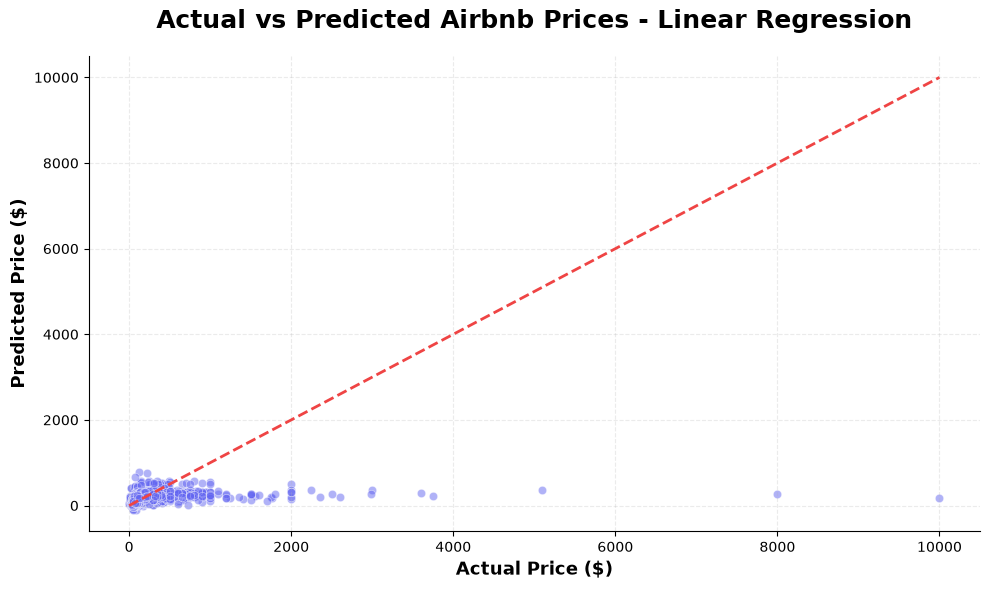

In [96]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5,
    color="#6366F1",
    edgecolor="white",
    linewidth=0.5
)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="#EF4444",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Actual vs Predicted Airbnb Prices - Linear Regression",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Actual Price ($)", fontsize=13, fontweight="bold")
plt.ylabel("Predicted Price ($)", fontsize=13, fontweight="bold")

plt.grid(linestyle="--", alpha=0.25)
sns.despine()

plt.tight_layout()
plt.show()

# 20. Actual vs Predicted Price

The actual and predicted Airbnb prices are compared using a scatter plot.

The X-axis represents the actual listing prices, while the Y-axis
represents the prices predicted by the Linear Regression model.

The diagonal reference line represents perfect predictions. Points
closer to this line indicate predictions that are closer to the actual
prices.

In [97]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


# 21. Random Forest Regression

Random Forest Regression is an ensemble Machine Learning algorithm
that combines multiple decision trees to make predictions.

In this project, Random Forest Regression is used as the second model
for predicting Airbnb listing prices.

The performance of Random Forest will later be compared with Linear
Regression using MAE, RMSE, and R² Score.

In [98]:
# Predict Airbnb prices using Random Forest

y_pred_rf = rf_model.predict(X_test)

print("Random Forest prediction completed successfully!")

print("\nFirst 10 Predicted Prices:")
print(y_pred_rf[:10])

Random Forest prediction completed successfully!

First 10 Predicted Prices:
[131.11  47.57  95.16 303.73 187.52 146.47  69.34 121.28 282.86 151.39]


# 22. Random Forest Price Prediction

After training the Random Forest Regression model, the testing dataset
is used to predict Airbnb listing prices.

The predicted prices will be compared with the actual prices to
evaluate the performance of the Random Forest model.

In [99]:
# Calculate Random Forest evaluation metrics

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Regression Performance")
print("-------------------------------------")
print(f"MAE      : {mae_rf:.2f}")
print(f"RMSE     : {rmse_rf:.2f}")
print(f"R² Score : {r2_rf:.4f}")

Random Forest Regression Performance
-------------------------------------
MAE      : 63.20
RMSE     : 200.88
R² Score : 0.0878


# 23. Random Forest Model Evaluation

The performance of the Random Forest Regression model is evaluated
using three regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics will be used to measure the accuracy of the Random Forest
model and compare its performance with the Linear Regression model.

In [100]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R² Score": [
        r2_linear,
        r2_rf
    ]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,68.147428,195.520102,0.135858
1,Random Forest Regression,63.198784,200.882135,0.087811


# 24. Machine Learning Model Comparison

The performance of Linear Regression and Random Forest Regression
models is compared using MAE, RMSE, and R² Score.

A lower MAE and RMSE indicate smaller prediction errors, while a
higher R² Score indicates that the model explains more variation
in Airbnb listing prices.

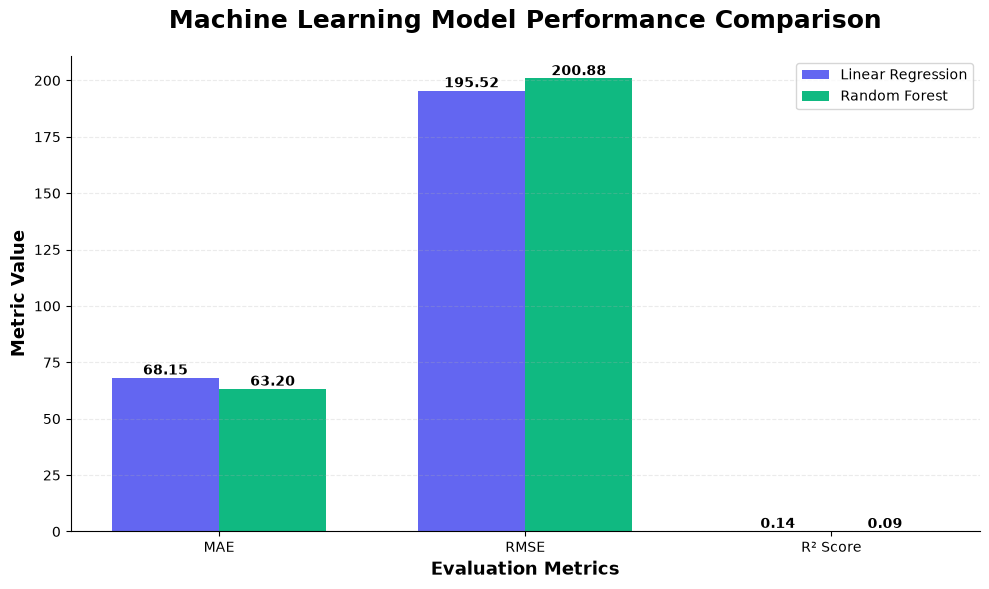

In [101]:
# Visualize model performance comparison

metrics = ["MAE", "RMSE", "R² Score"]

linear_values = [
    mae_linear,
    rmse_linear,
    r2_linear
]

rf_values = [
    mae_rf,
    rmse_rf,
    r2_rf
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    linear_values,
    width,
    label="Linear Regression",
    color="#6366F1"
)

bars2 = plt.bar(
    x + width/2,
    rf_values,
    width,
    label="Random Forest",
    color="#10B981"
)

plt.title(
    "Machine Learning Model Performance Comparison",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Evaluation Metrics", fontsize=13, fontweight="bold")
plt.ylabel("Metric Value", fontsize=13, fontweight="bold")

plt.xticks(x, metrics)
plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.25)

for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

# 25. Machine Learning Model Comparison Visualization

The performance of the two Machine Learning models is visualized
using their evaluation metrics.

The comparison helps identify which model performs better for Airbnb
price prediction.

In [102]:
# Display final model comparison

print("FINAL MODEL COMPARISON")
print("=" * 40)

print(f"Linear Regression")
print(f"MAE      : {mae_linear:.2f}")
print(f"RMSE     : {rmse_linear:.2f}")
print(f"R² Score : {r2_linear:.4f}")

print("\nRandom Forest Regression")
print(f"MAE      : {mae_rf:.2f}")
print(f"RMSE     : {rmse_rf:.2f}")
print(f"R² Score : {r2_rf:.4f}")

FINAL MODEL COMPARISON
Linear Regression
MAE      : 68.15
RMSE     : 195.52
R² Score : 0.1359

Random Forest Regression
MAE      : 63.20
RMSE     : 200.88
R² Score : 0.0878


# 26. Best Model Selection

The performance of Linear Regression and Random Forest Regression was
compared using MAE, RMSE, and R² Score.

For MAE and RMSE, lower values indicate better performance.

For R² Score, a higher value indicates better performance.

Based on these evaluation metrics, the model with the better overall
performance will be selected as the final model for Airbnb price
prediction.

In [103]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
top_features = feature_importance.head(15)

print("Top 15 Important Features:")
display(top_features)

Top 15 Important Features:


,Feature,Importance
1,longitude,0.197609
0,latitude,0.174870
2,minimum_nights,0.113505
6,availability_365,0.095430
4,reviews_per_month,0.057819
5,calculated_host_listings_count,0.057369
231,room_type_Private room,0.053362
3,number_of_reviews,0.044380
129,neighbourhood_Lower East Side,0.030501
14,neighbourhood_Astoria,0.020231


# 27. Feature Importance Analysis

Feature importance helps identify which input variables contribute
most to the predictions made by the Random Forest Regression model.

The Random Forest model assigns an importance score to each feature.
A higher score indicates that the feature has a greater contribution
to the model's predictions.

The top important features are visualized to better understand the
factors associated with Airbnb listing prices.

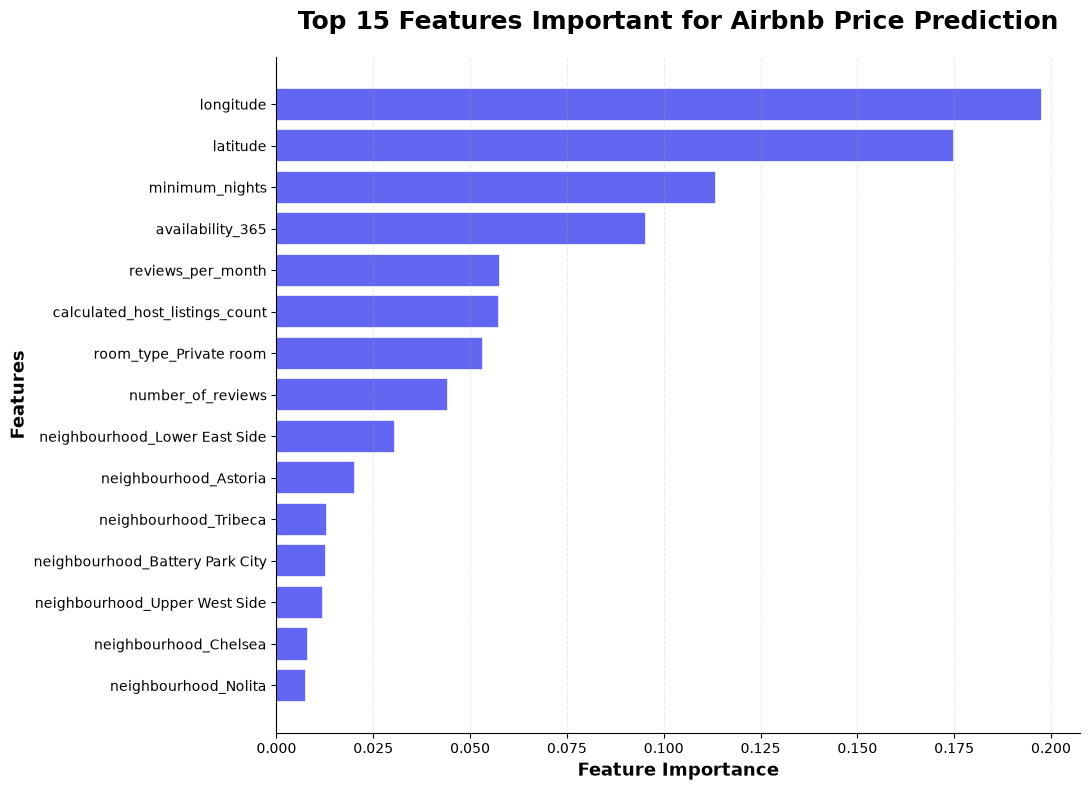

In [104]:
# Visualize top 15 feature importance

plt.figure(figsize=(11, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color="#6366F1",
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Top 15 Features Important for Airbnb Price Prediction",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Feature Importance",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Features",
    fontsize=13,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.25)

sns.despine()

plt.tight_layout()
plt.show()

# 28. Feature Importance Visualization

The feature importance scores obtained from the Random Forest model are
visualized using a horizontal bar chart.

The chart displays the top 15 features according to their importance
scores.

Features with higher importance scores have a greater contribution to
the Random Forest model's predictions.

In [105]:
# Create actual vs predicted price comparison

prediction_comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Linear Regression Prediction": y_pred_linear,
    "Random Forest Prediction": y_pred_rf
})

# Display first 15 predictions
prediction_comparison.head(15)

,Actual Price,Linear Regression Prediction,Random Forest Prediction
0,89,161.593888,131.11
1,30,47.522642,47.57
2,120,127.369027,95.16
3,470,214.795909,303.73
4,199,173.393438,187.52
5,170,152.668371,146.47
6,90,96.030942,69.34
7,60,152.421104,121.28
8,150,273.162999,282.86
9,74,131.919273,151.39


# 29. Actual vs Predicted Price Comparison

The actual Airbnb listing prices are compared with the prices predicted
by both Linear Regression and Random Forest Regression.

This comparison provides a direct view of how the two Machine Learning
models perform on individual test records.

The comparison also helps demonstrate the practical application of the
developed price prediction models.

In [106]:
# Final Machine Learning Results

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R² Score": [
        r2_linear,
        r2_rf
    ]
})

final_results.round(4)

,Model,MAE,RMSE,R² Score
0,Linear Regression,68.1474,195.5201,0.1359
1,Random Forest Regression,63.1988,200.8821,0.0878


# 30. Final Machine Learning Summary

Machine Learning was applied to predict Airbnb listing prices using
two regression algorithms:

1. Linear Regression
2. Random Forest Regression

The models were evaluated using Mean Absolute Error (MAE), Root Mean
Squared Error (RMSE), and R² Score.

## Model Performance

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | 68.15 | 195.52 | 0.1359 |
| Random Forest Regression | 63.20 | 200.88 | 0.0878 |

## Final Result

Linear Regression was selected as the final model because it achieved
a lower RMSE and a higher R² Score than Random Forest Regression.

Random Forest Regression achieved a slightly lower MAE, meaning its
average absolute prediction error was smaller. However, its higher
RMSE and lower R² Score indicate weaker overall performance for this
dataset.

The R² Score of 0.1359 indicates that the selected features explain
approximately 13.59% of the variation in Airbnb listing prices.

This shows that Airbnb pricing is influenced by many complex factors
that are not completely captured by the features used in this project.

# 31. Final Conclusion

This project presented an end-to-end analysis of Airbnb listing data
using Python, Data Analytics, and Machine Learning techniques.

The project started with data understanding and cleaning, where missing
values, duplicate records, and data types were examined and handled.

Exploratory Data Analysis was then performed to understand important
patterns related to room types, prices, neighbourhoods, hosts, reviews,
availability, and minimum-night requirements.

The analysis showed that Airbnb listing prices vary considerably across
different room types and neighbourhood groups. The distribution of
listings also showed that Airbnb activity is concentrated in certain
locations.

For predictive analysis, two Machine Learning models were developed:

- Linear Regression
- Random Forest Regression

The models were evaluated using MAE, RMSE, and R² Score. Linear
Regression was selected as the final model because it achieved a lower
RMSE of 195.52 and a higher R² Score of 0.1359.

Random Forest achieved a slightly lower MAE of 63.20, but its RMSE and
R² Score were weaker than Linear Regression.

The relatively low R² Score indicates that Airbnb prices are affected
by several complex factors that are not completely represented by the
selected features.

Overall, this project demonstrates how real-world data can be cleaned,
analyzed, visualized, and used to develop Machine Learning models for
predictive analysis. It also demonstrates the practical application
of Python and Data Analytics techniques to a real-world business
problem.

# 32. Future Scope

The current project can be further improved by adding more advanced
features and Machine Learning techniques.

Some possible future improvements are:

- Use advanced Machine Learning algorithms such as Gradient Boosting,
  XGBoost, or other ensemble methods.
- Perform hyperparameter tuning to improve model performance.
- Add additional features such as host experience, review sentiment,
  seasonal information, and detailed location-based features.
- Develop an interactive dashboard using Power BI or Streamlit.
- Create a web application where users can enter listing details and
  receive an estimated Airbnb price.
- Use advanced feature engineering to improve the prediction accuracy.
- Apply outlier detection and treatment to reduce the effect of
  extremely expensive listings.
- Compare additional regression algorithms to identify the most
  suitable model.
- Deploy the final prediction model as a web-based application.

These improvements can make the project more practical and suitable
for real-world Airbnb price analysis and prediction.

# 33. Project Limitations

Although the project provides useful insights into Airbnb listings and
price prediction, it has some limitations.

- The dataset contains information from 2019 and may not represent
  current Airbnb market conditions.
- The price distribution contains extreme values and outliers that
  can affect Machine Learning performance.
- The selected features do not capture all factors that influence
  Airbnb prices.
- Factors such as property quality, amenities, photographs, seasonal
  demand, and local events are not fully represented.
- The R² Score of the models is relatively low, indicating that the
  current features have limited explanatory power.
- The project uses a basic train-test split rather than advanced
  cross-validation techniques.
- The models were not extensively optimized using hyperparameter
  tuning.
- The final model is intended for academic and analytical purposes and
  should not be treated as an exact real-world pricing system.

# 34. Project Workflow / Methodology

The project follows a systematic end-to-end Data Analytics and Machine
Learning workflow.

## Project Workflow

### Step 1: Data Collection
The Airbnb NYC 2019 dataset was collected and loaded into the Python
environment.

### Step 2: Data Understanding
The dataset structure, columns, data types, statistical information,
and number of records were examined.

### Step 3: Data Cleaning
Missing values, duplicate records, and incorrect data types were
identified and handled.

### Step 4: Exploratory Data Analysis
Different statistical analyses and visualizations were performed to
identify patterns in Airbnb listings, prices, locations, reviews, and
availability.

### Step 5: Feature Selection
Relevant numerical and categorical features were selected for the
Machine Learning models.

### Step 6: Feature Encoding
Categorical variables were converted into numerical features using
One-Hot Encoding.

### Step 7: Train-Test Split
The dataset was divided into training and testing sets using an 80:20
ratio.

### Step 8: Machine Learning
Two regression models were developed:

- Linear Regression
- Random Forest Regression

### Step 9: Model Evaluation
The models were evaluated using:

- MAE
- RMSE
- R² Score

### Step 10: Model Comparison
The performance of both models was compared to identify the better
performing model.

### Step 11: Feature Importance
Random Forest feature importance was analyzed to identify the features
that contributed most to price prediction.

### Step 12: Final Result
Linear Regression was selected as the final model based on its lower
RMSE and higher R² Score.

## Overall Workflow

Data Collection → Data Understanding → Data Cleaning → EDA →
Feature Selection → Encoding → Train-Test Split → Machine Learning →
Model Evaluation → Model Comparison → Final Model

# 35. Project Summary and Key Findings

## Project Summary

The Airbnb Data Analysis and Price Prediction project analyzed the
Airbnb NYC 2019 dataset containing 48,895 listings and 16 features.

The project followed a complete Data Analytics and Machine Learning
workflow, including data cleaning, exploratory data analysis,
visualization, feature selection, categorical encoding, model
development, and model evaluation.

Two Machine Learning models were developed for Airbnb price prediction:

- Linear Regression
- Random Forest Regression

## Key Findings

1. Entire home/apt listings form the largest category of Airbnb
   listings.

2. Airbnb listing prices vary significantly across different room
   types.

3. Listing prices also vary across neighbourhood groups, showing the
   importance of location.

4. Airbnb listings are concentrated in a limited number of
   neighbourhoods.

5. Some hosts manage multiple Airbnb properties.

6. The number of reviews varies substantially between listings.

7. Listing availability differs considerably across properties.

8. The relationship between minimum nights and price does not follow
   a simple linear pattern.

9. Machine Learning results show that Linear Regression performed
   better overall than Random Forest for the selected features.

10. Linear Regression achieved an MAE of 68.15, RMSE of 195.52, and
    R² Score of 0.1359.

11. Random Forest achieved an MAE of 63.20, RMSE of 200.88, and
    R² Score of 0.0878.

12. The relatively low R² Score indicates that Airbnb pricing depends
    on several complex factors that are not completely represented by
    the selected features.

## Final Outcome

The project successfully demonstrates the application of Python,
Data Analytics, Exploratory Data Analysis, and Machine Learning to a
real-world Airbnb dataset.

The developed analysis provides useful insights into Airbnb listings
and pricing patterns, while the Machine Learning component demonstrates
how listing characteristics can be used for price prediction.